[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Favioleiva/gpubma/blob/main/examples/Exact_BMA_Canonical_p30_Figures.ipynb)

# Exact BMA canonical p30 figures

Reproduce the publication suite from all **1,073,741,824 models** using committed, SHA-256-verified exact artifacts. This is the full-enumeration reference notebook; the separate BFG notebook performs budgeted discovery.

The default path evaluates **zero models** and needs no CUDA. Configuration: n=2,000, x1–x30, always-in w1/w2, g=2,000, beta-binomial(1,1), float64. The reference is frozen; exact global quantities are not inferred from a BFG subset.

Run All from the public checkout. In standalone Colab, the bootstrap obtains the same committed inputs after human publication of this tree. Network access is required for missing dependencies/downloads. Raw multi-gigabyte arrays are optional and are not publicly hosted by this candidate.

In [6]:
from pathlib import Path
import hashlib
import json
import sys
import subprocess
import importlib.metadata
import importlib.util
from urllib.request import urlopen


# ============================================================
# Frozen bootstrap files
# ============================================================

EXPECTED_FILES = {
    "benchmark/exact_p30/reference/REFERENCE_MANIFEST.json":
        "4b623ca462c8169dd6961cda588c1b35a5207eb268568d8e8597445abc9adf03",

    "benchmark/exact_p30/reference/REFERENCE_MANIFEST.sha256":
        "569c39367c372b2f816a855cd8383ee89428b9a1f3889b4fcac15438cbc07bb8",

    "examples/exact_reference_figures.py":
        "a9a1490f567bd5f37de25b50239f9b1b2c501abe1c28d41e55a8a4b2ac624bae",

    "examples/exact_reference_workflow.py":
        "fac9f53df32da7056a8aa39f41d0e4ee9a083cee8e713c30950e22e0e1f8c78d",
}


# ============================================================
# Git revision
# ============================================================

GPUBMA_REF = "main"

PUBLIC_RAW = (
    f"https://raw.githubusercontent.com/"
    f"Favioleiva/gpubma/{GPUBMA_REF}/"
)


# ============================================================
# Helpers
# ============================================================

def sha256_bytes(payload):
    return hashlib.sha256(payload).hexdigest()


# Only these reference-artifact formats are allowed to use
# CRLF/LF equivalence. Nothing else is normalized.
TEXT_REFERENCE_SUFFIXES = {
    ".json",
    ".csv",
    ".tsv",
    ".txt",
    ".tex",
    ".md",
}


def canonicalize_newlines_to_expected(payload, expected):
    """
    Return bytes whose SHA-256 equals `expected`.

    Accepted possibilities:
      1. Original bytes match exactly.
      2. CRLF -> LF is the ONLY required transformation.
      3. LF -> CRLF is the ONLY required transformation.

    No whitespace normalization, JSON reserialization,
    numeric transformation, or other content modification
    is permitted.
    """

    raw_hash = sha256_bytes(payload)

    if raw_hash == expected:
        return payload, "EXACT"

    # CRLF -> LF
    lf_payload = payload.replace(b"\r\n", b"\n")
    lf_hash = sha256_bytes(lf_payload)

    if lf_hash == expected:
        return lf_payload, "CRLF_TO_LF"

    # First obtain a canonical LF representation, then create CRLF.
    # This avoids turning an existing CRLF into CRCRLF.
    crlf_payload = lf_payload.replace(b"\n", b"\r\n")
    crlf_hash = sha256_bytes(crlf_payload)

    if crlf_hash == expected:
        return crlf_payload, "LF_TO_CRLF"

    raise ValueError(
        "\nReference checksum mismatch after strict newline audit:\n"
        f"  expected:       {expected}\n"
        f"  raw:            {raw_hash}\n"
        f"  CRLF -> LF:     {lf_hash}\n"
        f"  LF -> CRLF:     {crlf_hash}\n"
        "\n"
        "This is NOT explainable solely by CRLF/LF conversion."
    )


# ============================================================
# Locate local checkout, otherwise create isolated reference dir
# ============================================================

roots = [Path.cwd(), *Path.cwd().parents]

ROOT = next(
    (
        p for p in roots
        if (
            p
            / "benchmark/exact_p30/reference/REFERENCE_MANIFEST.json"
        ).is_file()
    ),
    None,
)

LOCAL_CHECKOUT = ROOT is not None

if ROOT is None:
    ROOT = Path.cwd() / "gpubma_exact_reference"
    ROOT.mkdir(exist_ok=True)


    def download_checked(
        relative,
        expected,
        *,
        allow_newline_equivalence=False,
    ):
        target = ROOT / relative

        # ----------------------------------------------------
        # Existing local file
        # ----------------------------------------------------

        if target.is_file():
            existing = target.read_bytes()

            if sha256_bytes(existing) == expected:
                return

            if allow_newline_equivalence:
                try:
                    canonical, mode = canonicalize_newlines_to_expected(
                        existing,
                        expected,
                    )

                    # Store the representation whose bytes actually
                    # correspond to the frozen manifest checksum.
                    target.write_bytes(canonical)

                    print(
                        f"[newline-normalized:{mode}] "
                        f"{relative}"
                    )
                    return

                except ValueError:
                    # Local file is stale/different; try public source.
                    pass

        # ----------------------------------------------------
        # Download public file
        # ----------------------------------------------------

        with urlopen(
            PUBLIC_RAW + relative,
            timeout=90,
        ) as response:
            payload = response.read()

        # ----------------------------------------------------
        # Strict verification
        # ----------------------------------------------------

        if not allow_newline_equivalence:
            actual = sha256_bytes(payload)

            if actual != expected:
                raise ValueError(
                    "\nPublic reference checksum mismatch:\n"
                    f"  file:     {relative}\n"
                    f"  expected: {expected}\n"
                    f"  received: {actual}"
                )

            canonical_payload = payload

        # ----------------------------------------------------
        # Text reference verification:
        # strict bytes OR newline-only equivalence
        # ----------------------------------------------------

        else:
            try:
                canonical_payload, mode = (
                    canonicalize_newlines_to_expected(
                        payload,
                        expected,
                    )
                )
            except ValueError as exc:
                raise ValueError(
                    f"\nFile: {relative}\n{exc}"
                ) from exc

            if mode != "EXACT":
                print(
                    f"[newline-normalized:{mode}] "
                    f"{relative}"
                )

        target.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        target.write_bytes(canonical_payload)


    # ========================================================
    # Bootstrap files:
    # ALWAYS byte-for-byte strict
    # ========================================================

    for relative, digest in EXPECTED_FILES.items():
        download_checked(
            relative,
            digest,
            allow_newline_equivalence=False,
        )


    # ========================================================
    # Load frozen scientific manifest
    # ========================================================

    manifest_path = (
        ROOT
        / "benchmark/exact_p30/reference/REFERENCE_MANIFEST.json"
    )

    manifest = json.loads(
        manifest_path.read_text(encoding="utf-8")
    )


    # ========================================================
    # Download manifest artifacts
    # ========================================================

    for name, digest in manifest["files"].items():

        # Security: manifest filenames must be simple basenames.
        if Path(name).name != name:
            raise ValueError(
                f"Unsafe reference filename: {name}"
            )

        relative = (
            "benchmark/exact_p30/reference/"
            + name
        )

        suffix = Path(name).suffix.lower()

        allow_newline_equivalence = (
            suffix in TEXT_REFERENCE_SUFFIXES
        )

        download_checked(
            relative,
            digest,
            allow_newline_equivalence=allow_newline_equivalence,
        )

from pathlib import Path
import hashlib

manifest = ROOT / "benchmark/exact_p30/reference/REFERENCE_MANIFEST.json"
manifest_sha = ROOT / "benchmark/exact_p30/reference/REFERENCE_MANIFEST.sha256"

print("manifest actual hash:")
print(hashlib.sha256(manifest.read_bytes()).hexdigest())

print("\nREFERENCE_MANIFEST.sha256 says:")
print(manifest_sha.read_text())

# ============================================================
# Recheck frozen bootstrap files byte-for-byte
# ============================================================

for relative, digest in EXPECTED_FILES.items():

    actual = sha256_bytes(
        (ROOT / relative).read_bytes()
    )

    assert actual == digest, (
        f"{relative}\n"
        f"expected: {digest}\n"
        f"actual:   {actual}"
    )

# ============================================================
# Repair stale manifest companion checksum locally
# ============================================================
#
# The public REFERENCE_MANIFEST.json is current and has already
# been verified byte-for-byte against EXPECTED_FILES above.
#
# However, the public REFERENCE_MANIFEST.sha256 still contains
# the digest of an older manifest.  load_reference() expects
# these two files to be internally consistent.
#
# We therefore regenerate ONLY the local companion checksum.
# No scientific reference artifact is modified.
# ============================================================

manifest_path = (
    ROOT
    / "benchmark"
    / "exact_p30"
    / "reference"
    / "REFERENCE_MANIFEST.json"
)

manifest_sha_path = (
    ROOT
    / "benchmark"
    / "exact_p30"
    / "reference"
    / "REFERENCE_MANIFEST.sha256"
)

verified_manifest_digest = sha256_bytes(
    manifest_path.read_bytes()
)

# Safety check: the manifest itself must still be exactly the
# public manifest that was frozen in EXPECTED_FILES.
expected_public_manifest_digest = EXPECTED_FILES[
    "benchmark/exact_p30/reference/REFERENCE_MANIFEST.json"
]

if verified_manifest_digest != expected_public_manifest_digest:
    raise ValueError(
        "Refusing to repair companion checksum because "
        "REFERENCE_MANIFEST.json is not the verified public manifest.\n"
        f"expected: {expected_public_manifest_digest}\n"
        f"actual:   {verified_manifest_digest}"
    )

old_companion_digest = (
    manifest_sha_path
    .read_text(encoding="utf-8")
    .split()[0]
)

if old_companion_digest != verified_manifest_digest:

    manifest_sha_path.write_text(
        f"{verified_manifest_digest}  REFERENCE_MANIFEST.json\n",
        encoding="utf-8",
        newline="\n",
    )

    print(
        "[manifest-companion-repaired] "
        f"{old_companion_digest} -> "
        f"{verified_manifest_digest}"
    )


# ============================================================
# Install gpubma
# ============================================================

try:
    installed = importlib.metadata.version("gpubma")

except importlib.metadata.PackageNotFoundError:
    installed = None


if installed != "0.3.0rc1":

    requirement = (
        str(ROOT) + "[notebooks]"
        if LOCAL_CHECKOUT
        else (
            "gpubma[notebooks] @ "
            f"git+https://github.com/"
            f"Favioleiva/gpubma.git@{GPUBMA_REF}"
        )
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            requirement,
        ]
    )


# ============================================================
# Ensure notebook dependencies
# ============================================================

missing = []

for module, distribution in [
    ("matplotlib", "matplotlib>=3.7"),
    ("pandas", "pandas>=2.1"),
    ("scipy", "scipy>=1.11"),
]:

    if importlib.util.find_spec(module) is None:
        missing.append(distribution)


if missing:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            *missing,
        ]
    )


# ============================================================
# Imports
# ============================================================

import gpubma

sys.path.insert(
    0,
    str(ROOT / "examples"),
)

from exact_reference_workflow import (
    load_reference,
    export_tables,
)

from exact_reference_figures import (
    render_suite,
    FIGURE_CATALOG,
)

from IPython.display import (
    display,
    Markdown,
    Image,
)


print(
    f"gpubma "
    f"{importlib.metadata.version('gpubma')} "
    f"— exact reference ready"
)

manifest actual hash:
4b623ca462c8169dd6961cda588c1b35a5207eb268568d8e8597445abc9adf03

REFERENCE_MANIFEST.sha256 says:
25425f071e4bb29063506709af284c9303f5ba180b3b231f0816b361f4a4e5b9  REFERENCE_MANIFEST.json

[manifest-companion-repaired] 25425f071e4bb29063506709af284c9303f5ba180b3b231f0816b361f4a4e5b9 -> 4b623ca462c8169dd6961cda588c1b35a5207eb268568d8e8597445abc9adf03
gpubma 0.3.0rc1 — exact reference ready


In [7]:
REGENERATE_FULL_ENUMERATION = False
OUTPUT_DIR = ROOT / "outputs" / "exact_p30"
REFERENCE_DIR = ROOT / "benchmark" / "exact_p30" / "reference"
if REGENERATE_FULL_ENUMERATION:
    raise RuntimeError("This evaluates all 1,073,741,824 models. Full regeneration requires the separately provisioned canonical CUDA enumerator and a fresh output location; this figure notebook loads the frozen reference only.")
metadata, exact_map, exact_truth = load_reference(REFERENCE_DIR)
print("Models represented:", f"{metadata['models']:,}")
print("Models evaluated by this notebook: 0")
print("Frozen RTX 3060 enumeration runtime: 379.812 s; throughput: 2,827,037 models/s")
display(exact_map, exact_truth)
catalog, validation = render_suite(REFERENCE_DIR, OUTPUT_DIR)
table_path = export_tables(REFERENCE_DIR, OUTPUT_DIR)
assert len(catalog) == 9
assert all(v["embedded_titles"] == v["embedded_captions"] == 0 for v in validation["figures"].values())


Models represented: 1,073,741,824
Models evaluated by this notebook: 0
Frozen RTX 3060 enumeration runtime: 379.812 s; throughput: 2,827,037 models/s


{'model_id': 536887295,
 'model_size': 15,
 'pmp': 0.4715187997893168,
 'log_score': 1118.521780616737,
 'exact_global_rank': 1,
 'variables': 'x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x30',
 'cumulative_global_pmp': 0.4715187997893168,
 'log_model_prior': -22.293680785633526,
 'log_marginal_likelihood_common_constant_omitted': 1140.8154614023706,
 'true_model_equals_map': False}

{'model_id': 32767,
 'model_size': 15,
 'log_score': 1115.3003957189062,
 'pmp': 0.01881348830750715,
 'exact_posterior_rank': 8,
 'score_ties': 0,
 'cumulative_pmp_through_rank': 0.6951200301187114,
 'log_score_gap_from_top': 3.2213848978308306,
 'hamming_from_top_model': 2,
 'note': 'New exact rank counted over all saved RTX 3060 scores; no second model-scoring pass.',
 'variables': 'x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15',
 'log_model_prior': -22.293680785633526,
 'log_marginal_likelihood_common_constant_omitted': 1137.5940765045398,
 'true_model_equals_map': False,
 'exact_global_rank': 8}

### Canonical p30 predictor geometry

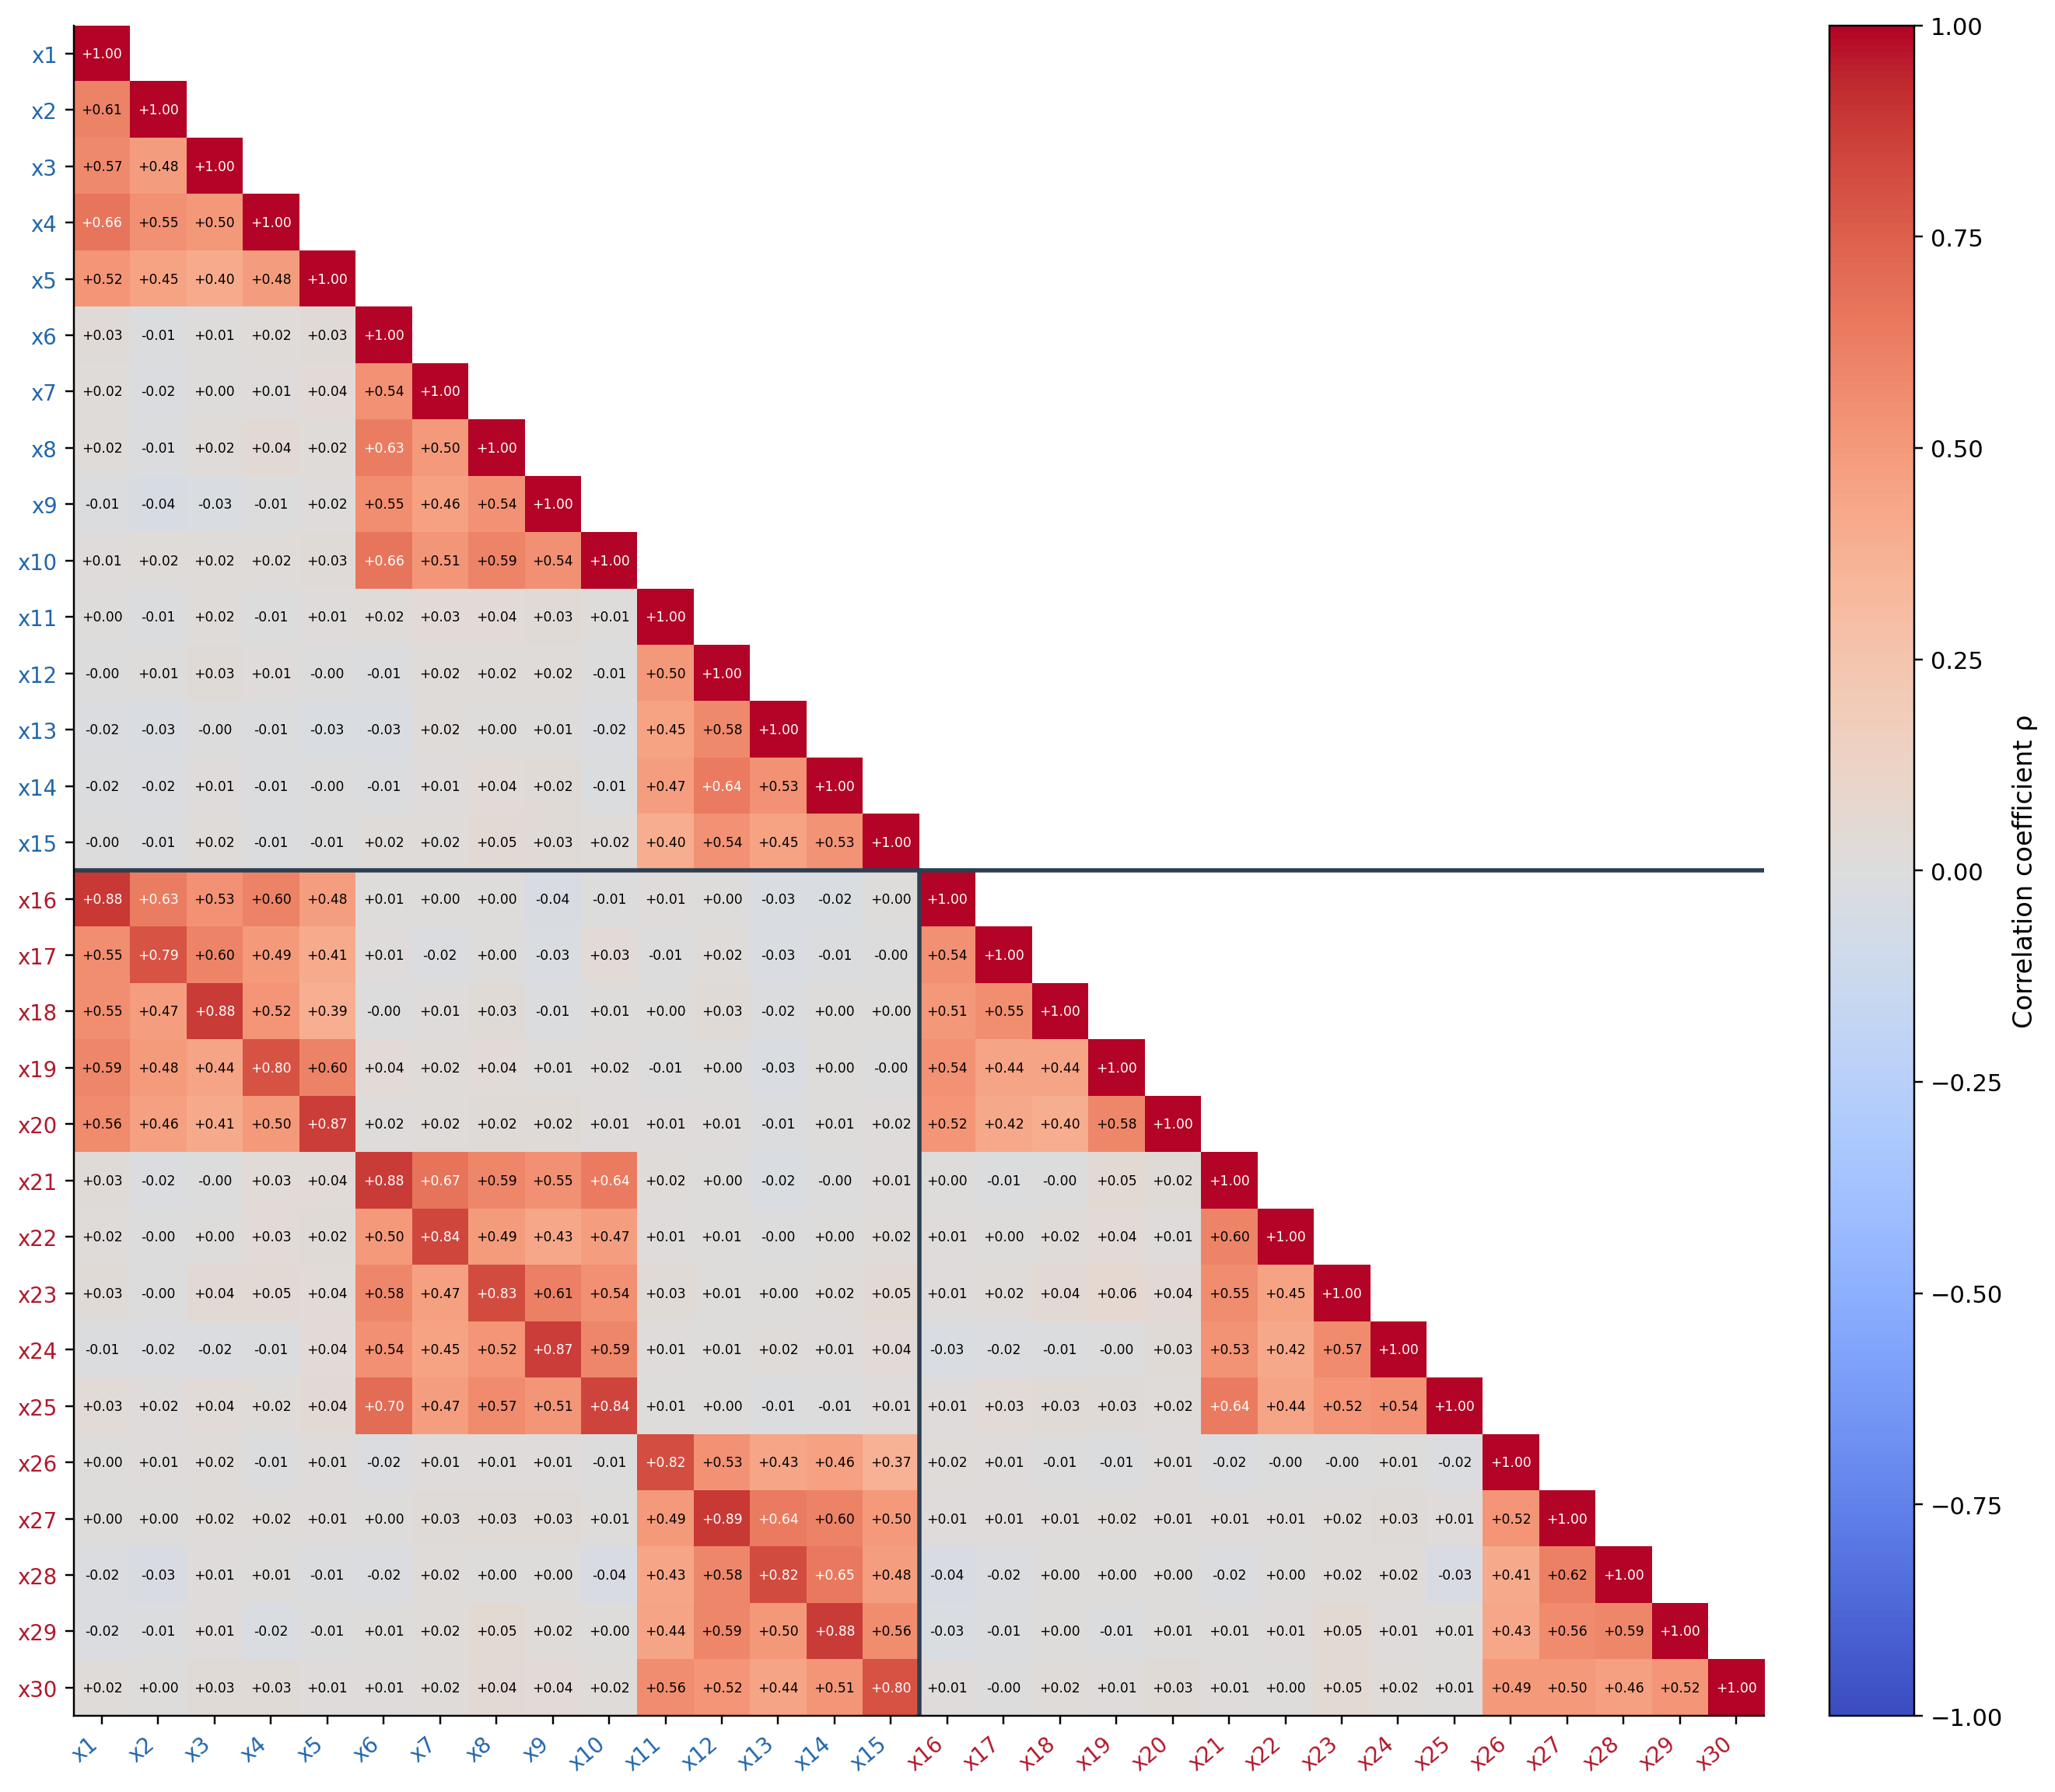

**Notes:** Observed candidate correlations, n = 2,000; original metadata order. Controls w1, w2 excluded. Not a causal or posterior map. Blue labels: causal DGP predictors x1–x15; red labels: structural-zero proxies x16–x30.

In [8]:
display(Markdown('### Canonical p30 predictor geometry'))
display(Image(filename=str(OUTPUT_DIR / '00_predictor_correlogram.png')))
display(Markdown('**Notes:** Observed candidate correlations, n = 2,000; original metadata order. Controls w1, w2 excluded. Not a causal or posterior map. Blue labels: causal DGP predictors x1–x15; red labels: structural-zero proxies x16–x30.'))

### Full-enumeration model-space cloud

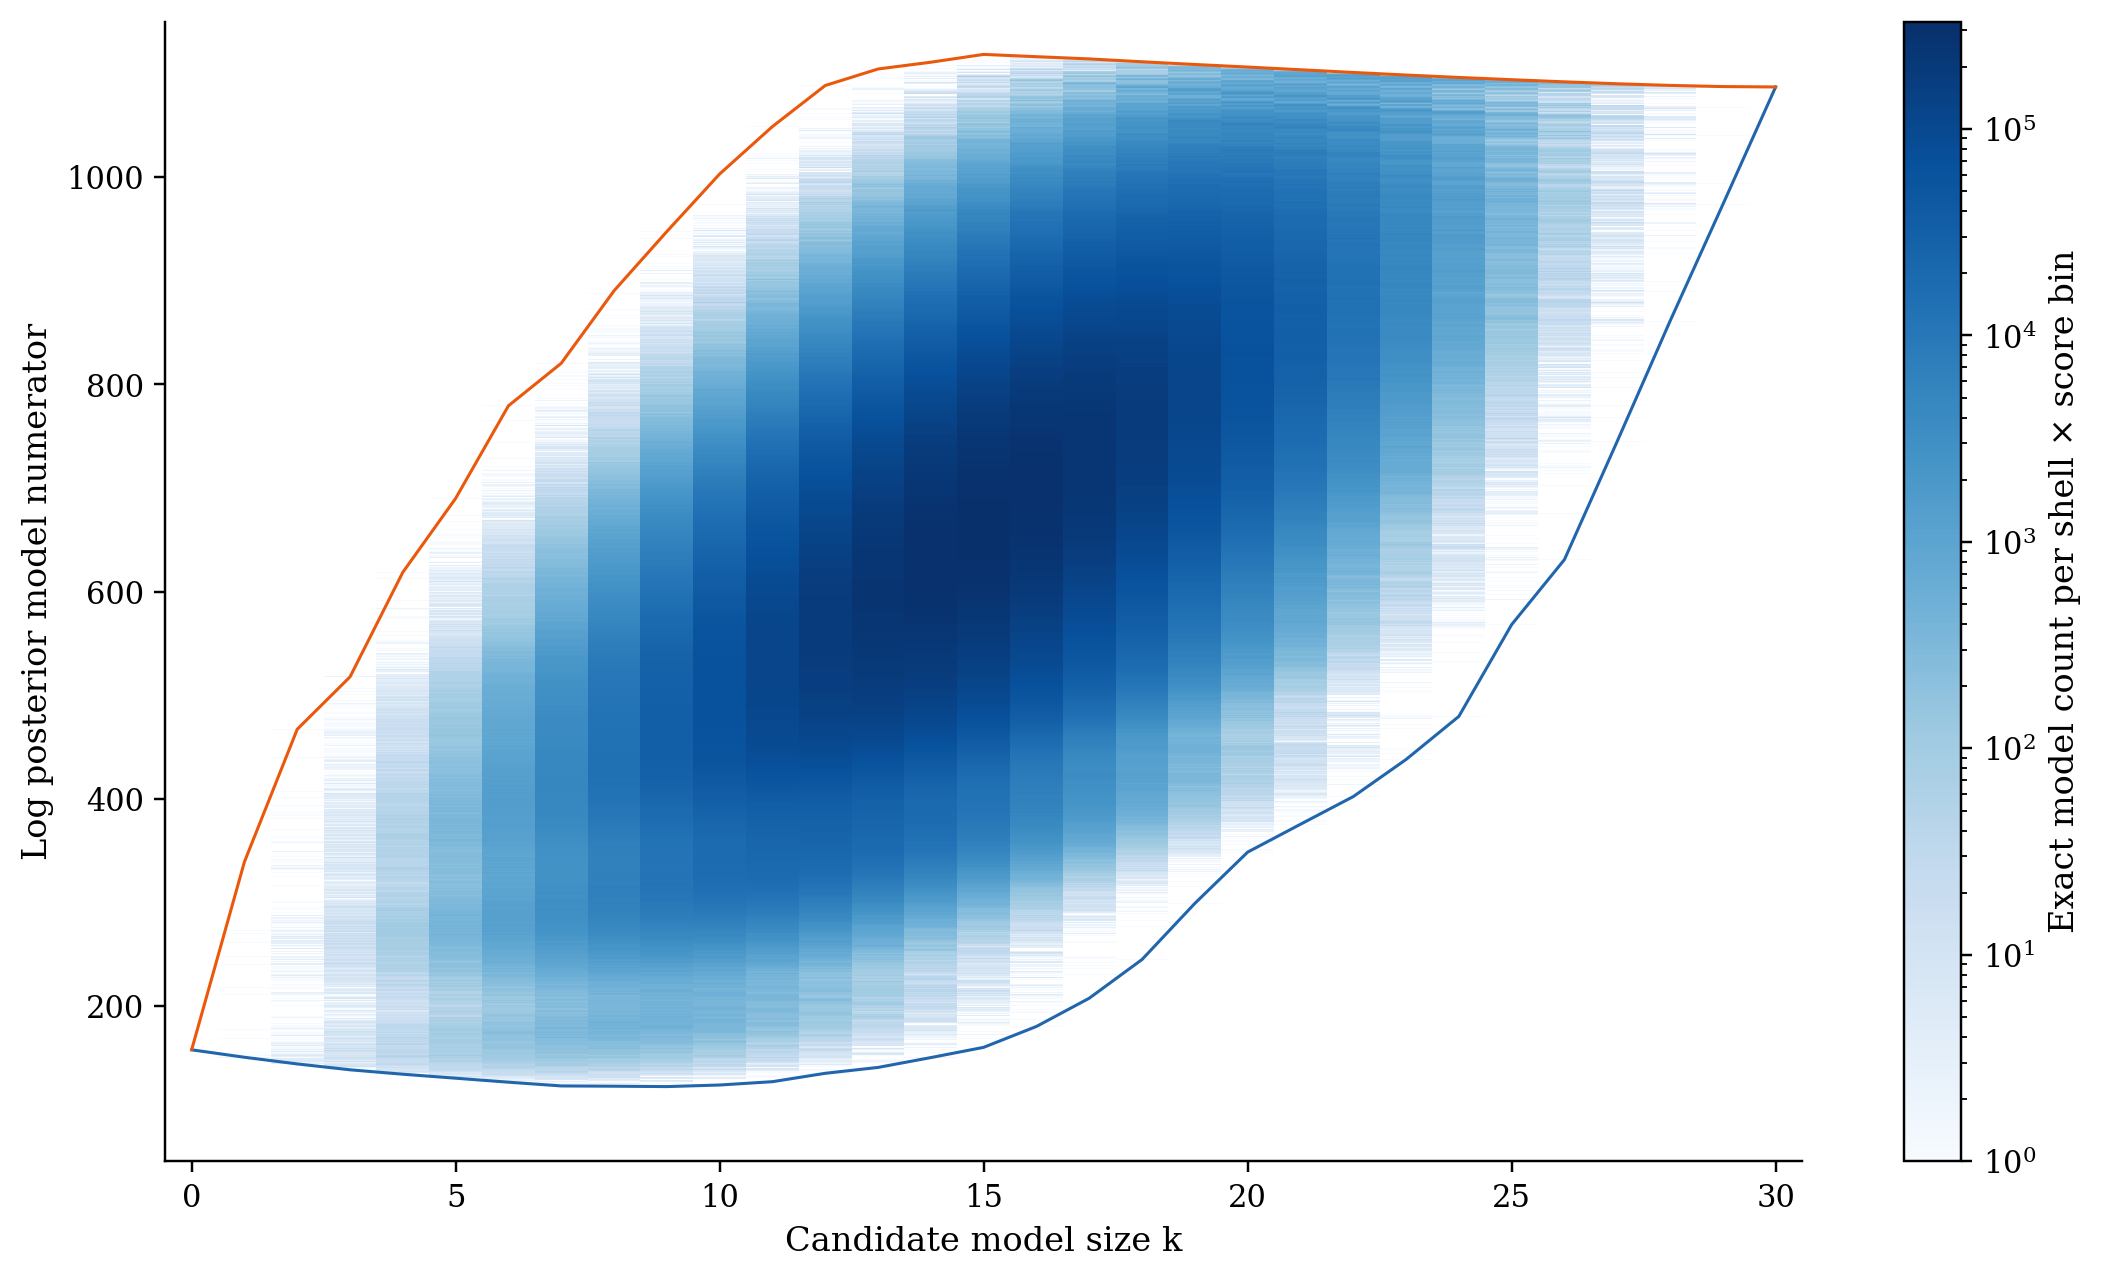

**Notes:** All 1,073,741,824 models contribute once. Exact counts in 2,000 common score bins; no random thinning. Lines: exact support.

In [9]:
display(Markdown('### Full-enumeration model-space cloud'))
display(Image(filename=str(OUTPUT_DIR / '01_exhaustive_model_space_cloud.png')))
display(Markdown('**Notes:** All 1,073,741,824 models contribute once. Exact counts in 2,000 common score bins; no random thinning. Lines: exact support.'))

### Exact log BMA numerator across all reticula

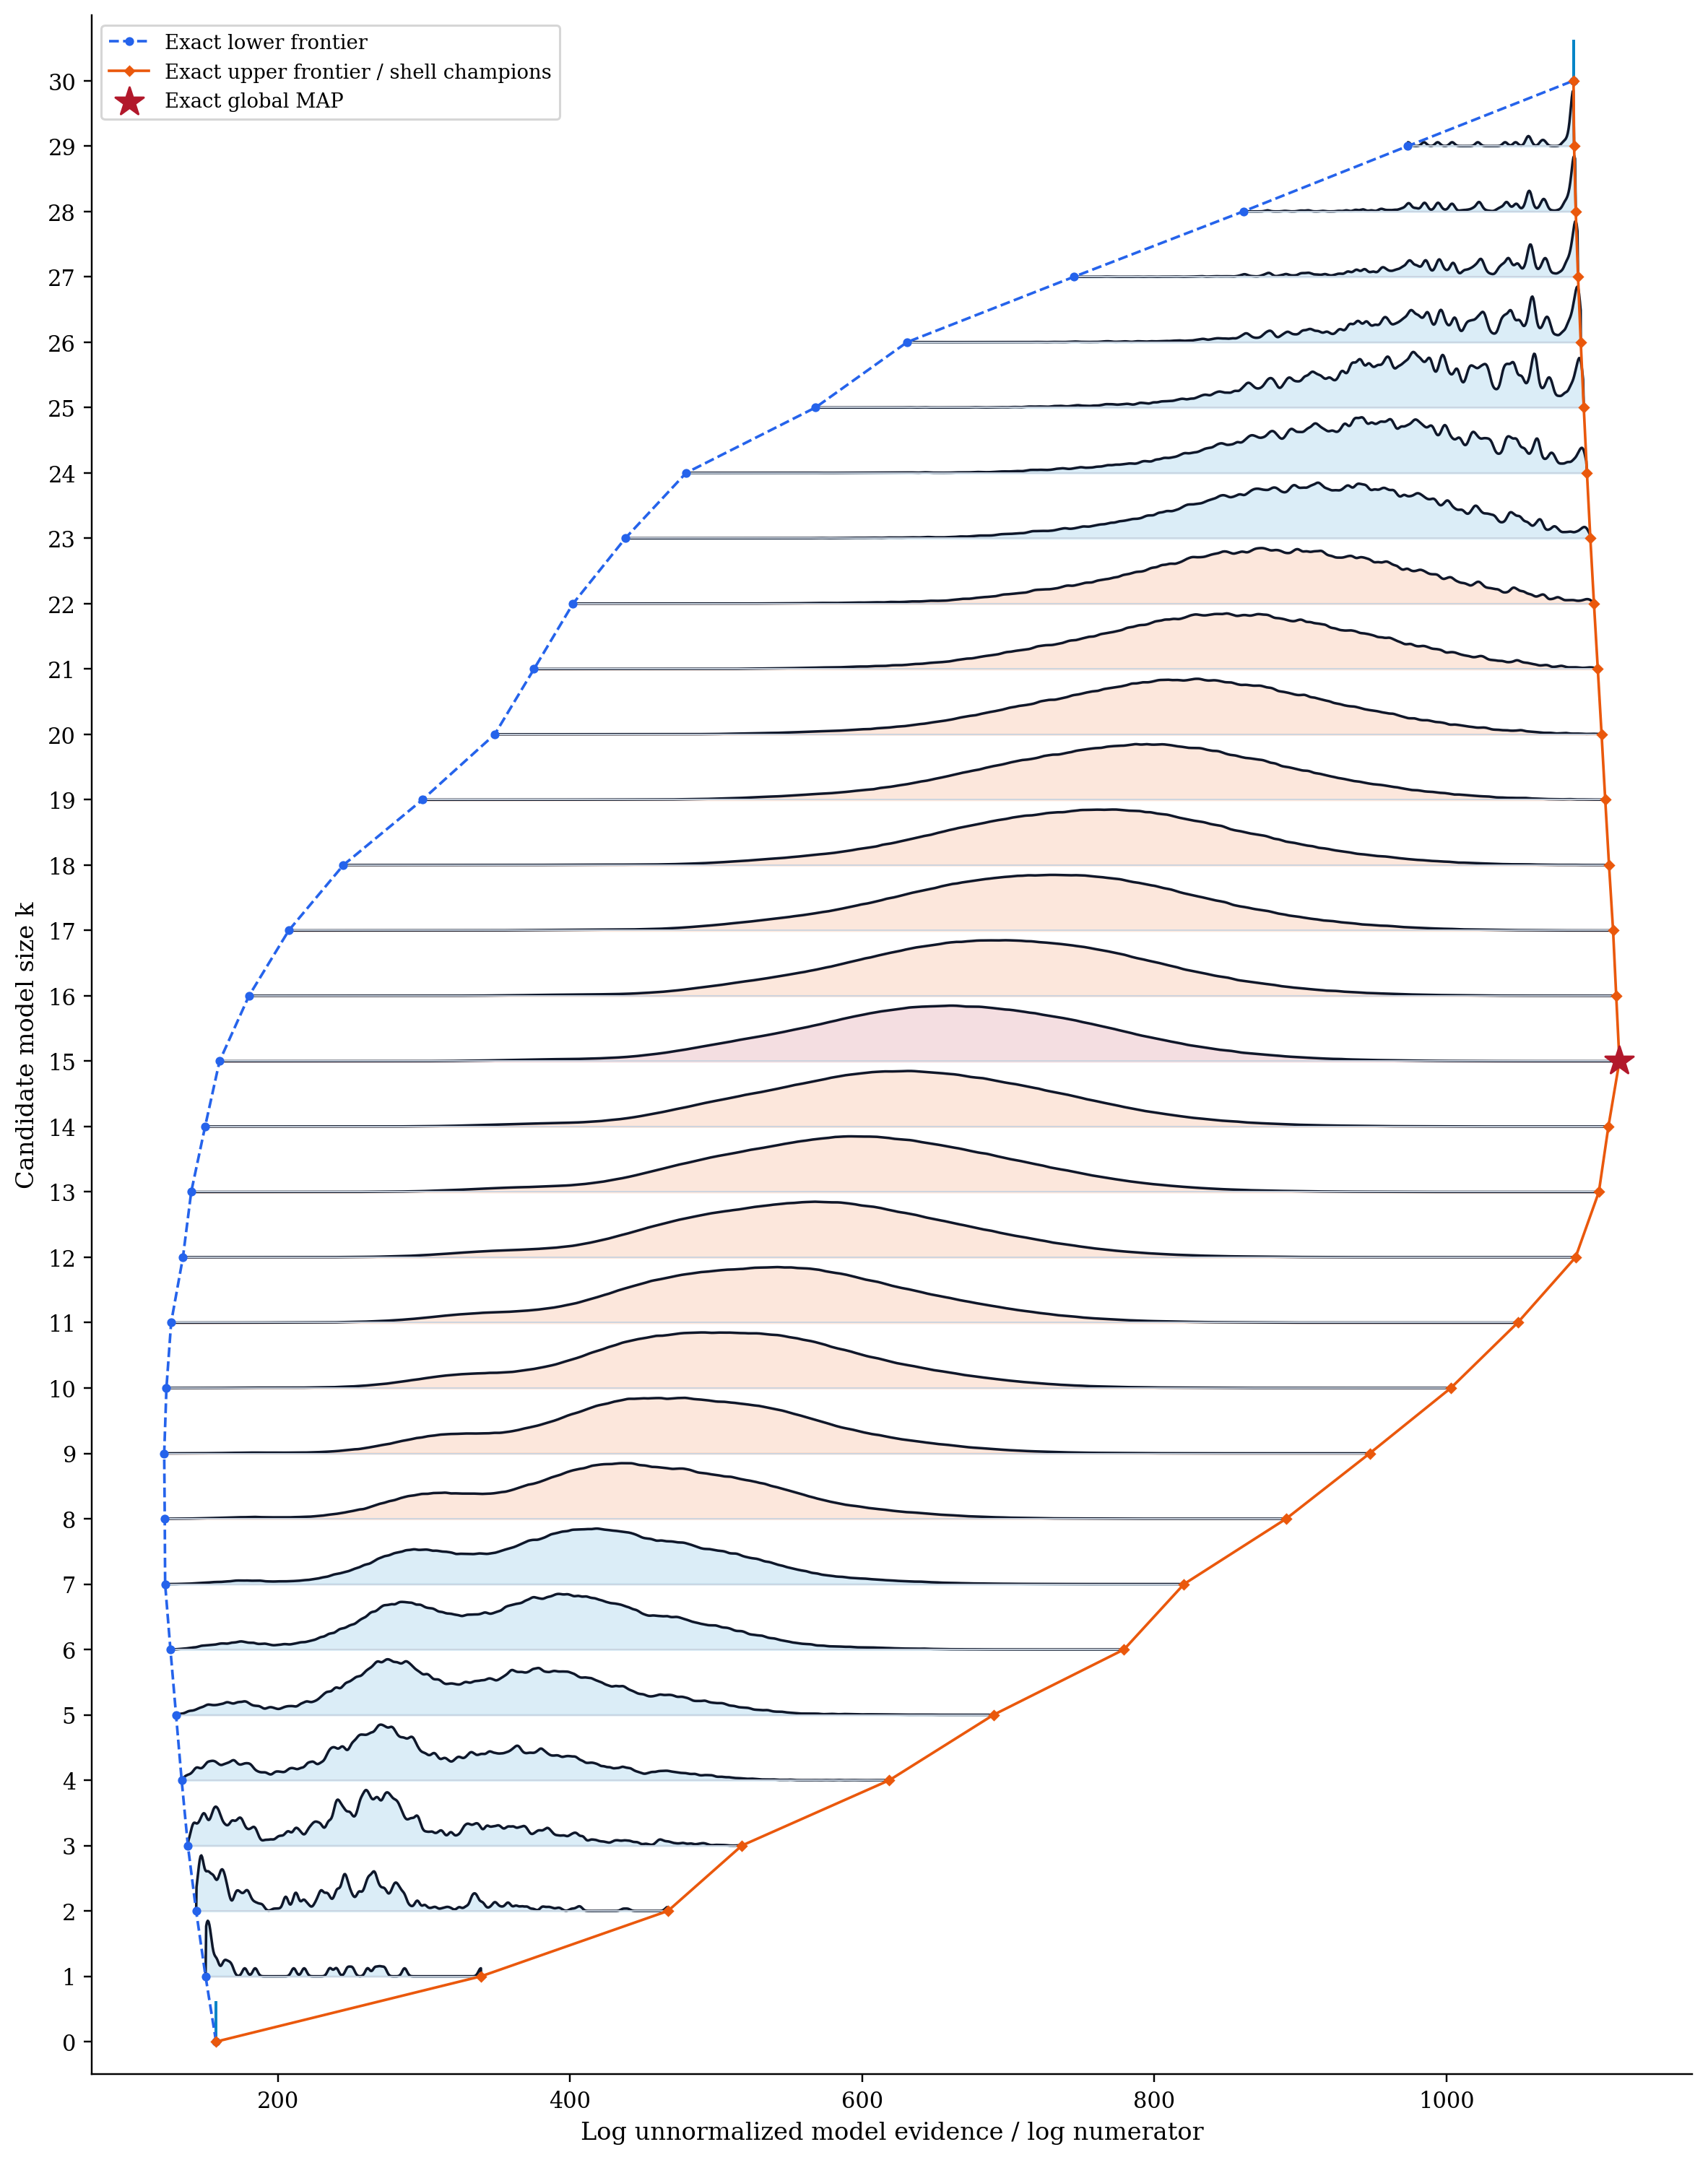

**Notes:** Full-shell histograms; Gaussian smoothing σ = 3 bins for display. Unit-peak ridge height is not posterior mass. Exact finite support; singleton spikes.

In [10]:
display(Markdown('### Exact log BMA numerator across all reticula'))
display(Image(filename=str(OUTPUT_DIR / '02_exhaustive_reticular_ridgeline.png')))
display(Markdown('**Notes:** Full-shell histograms; Gaussian smoothing σ = 3 bins for display. Unit-peak ridge height is not posterior mass. Exact finite support; singleton spikes.'))

### Exact lower and upper reticular frontiers

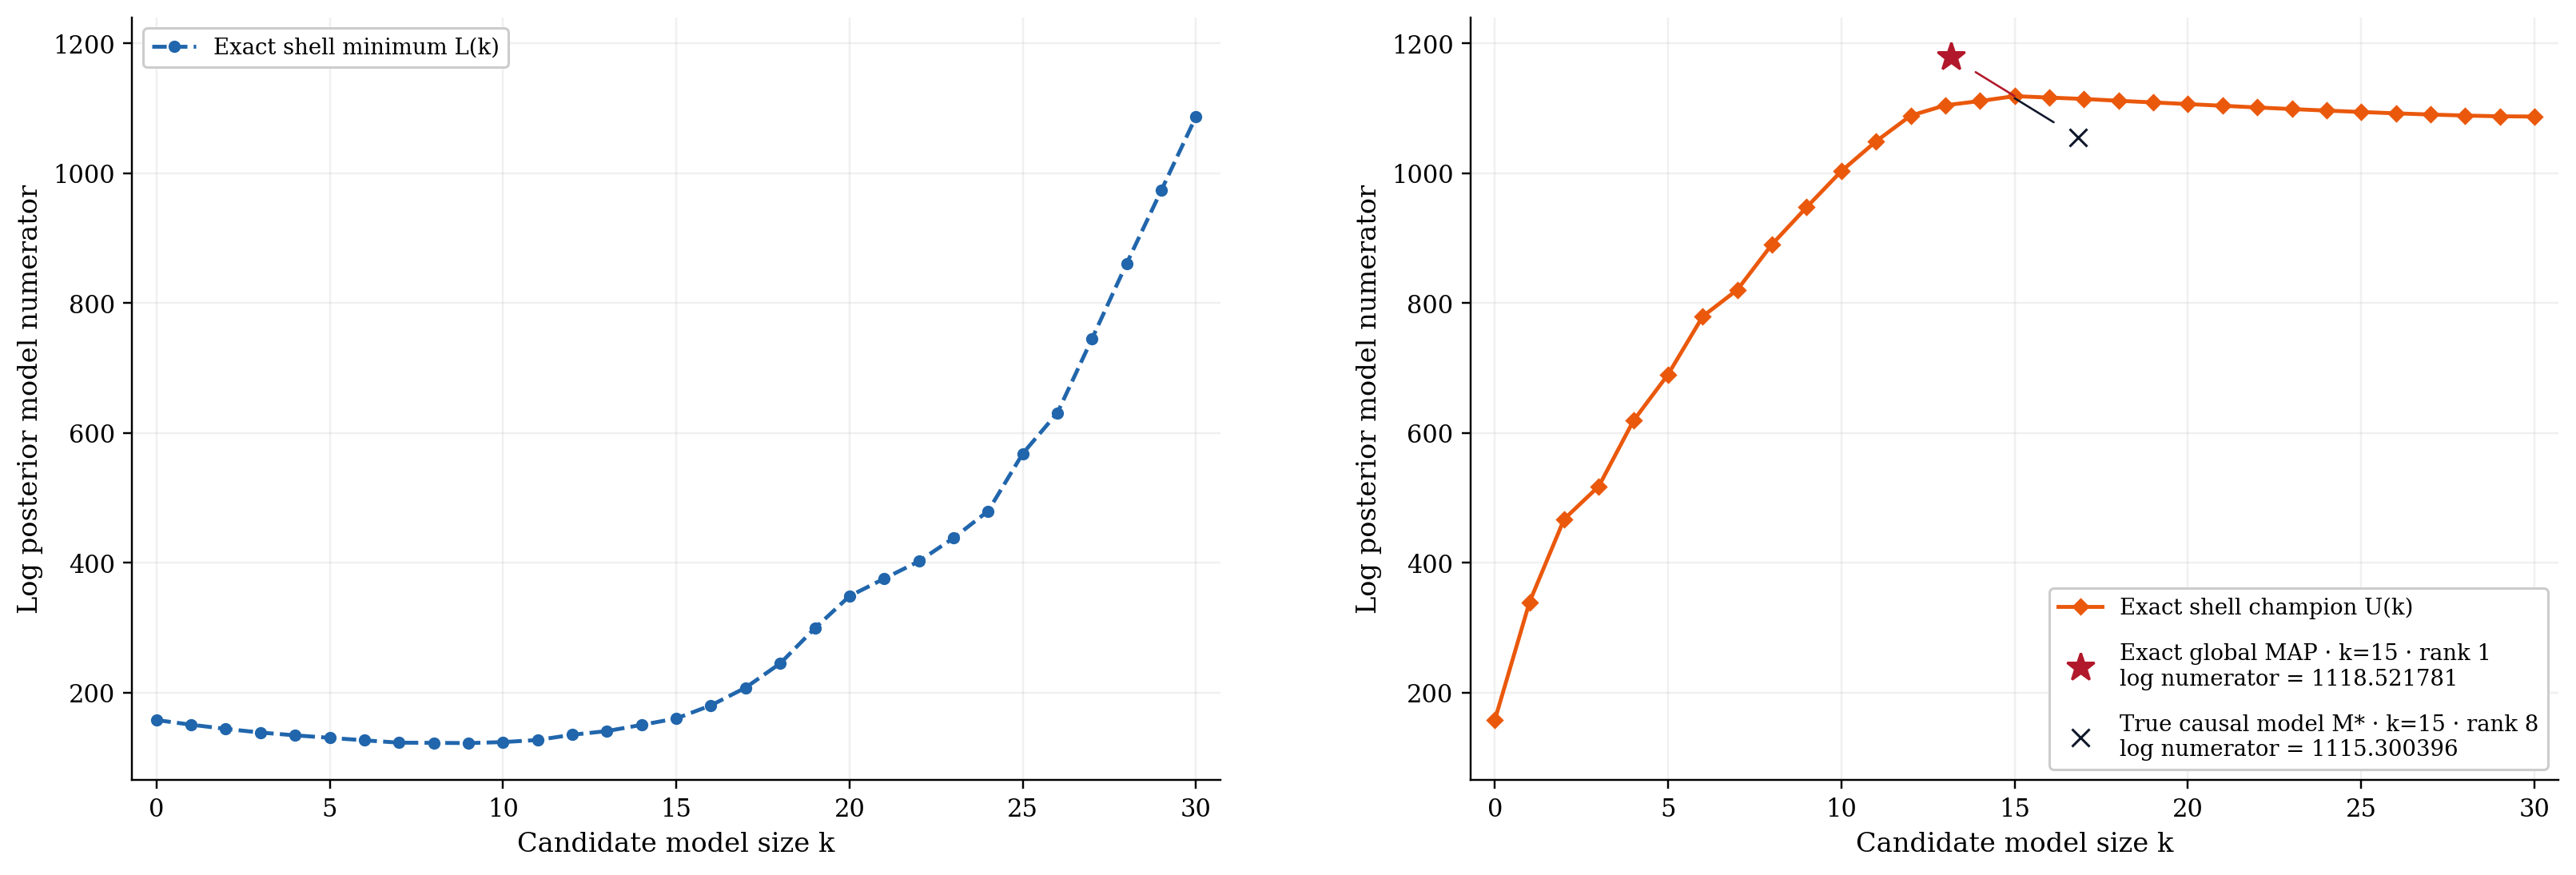

**Notes:** Left: exact lower reticular frontier. Right: exact upper reticular frontier. Every shell is fully enumerated. The MAP and true model both have k=15, but their compositions differ by two predictor indicators. Short marker callouts are anchored at the exact scores.

In [11]:
display(Markdown('### Exact lower and upper reticular frontiers'))
display(Image(filename=str(OUTPUT_DIR / '03_exhaustive_reticular_frontiers.png')))
display(Markdown('**Notes:** Left: exact lower reticular frontier. Right: exact upper reticular frontier. Every shell is fully enumerated. The MAP and true model both have k=15, but their compositions differ by two predictor indicators. Short marker callouts are anchored at the exact scores.'))

### Exact global variable / model structure

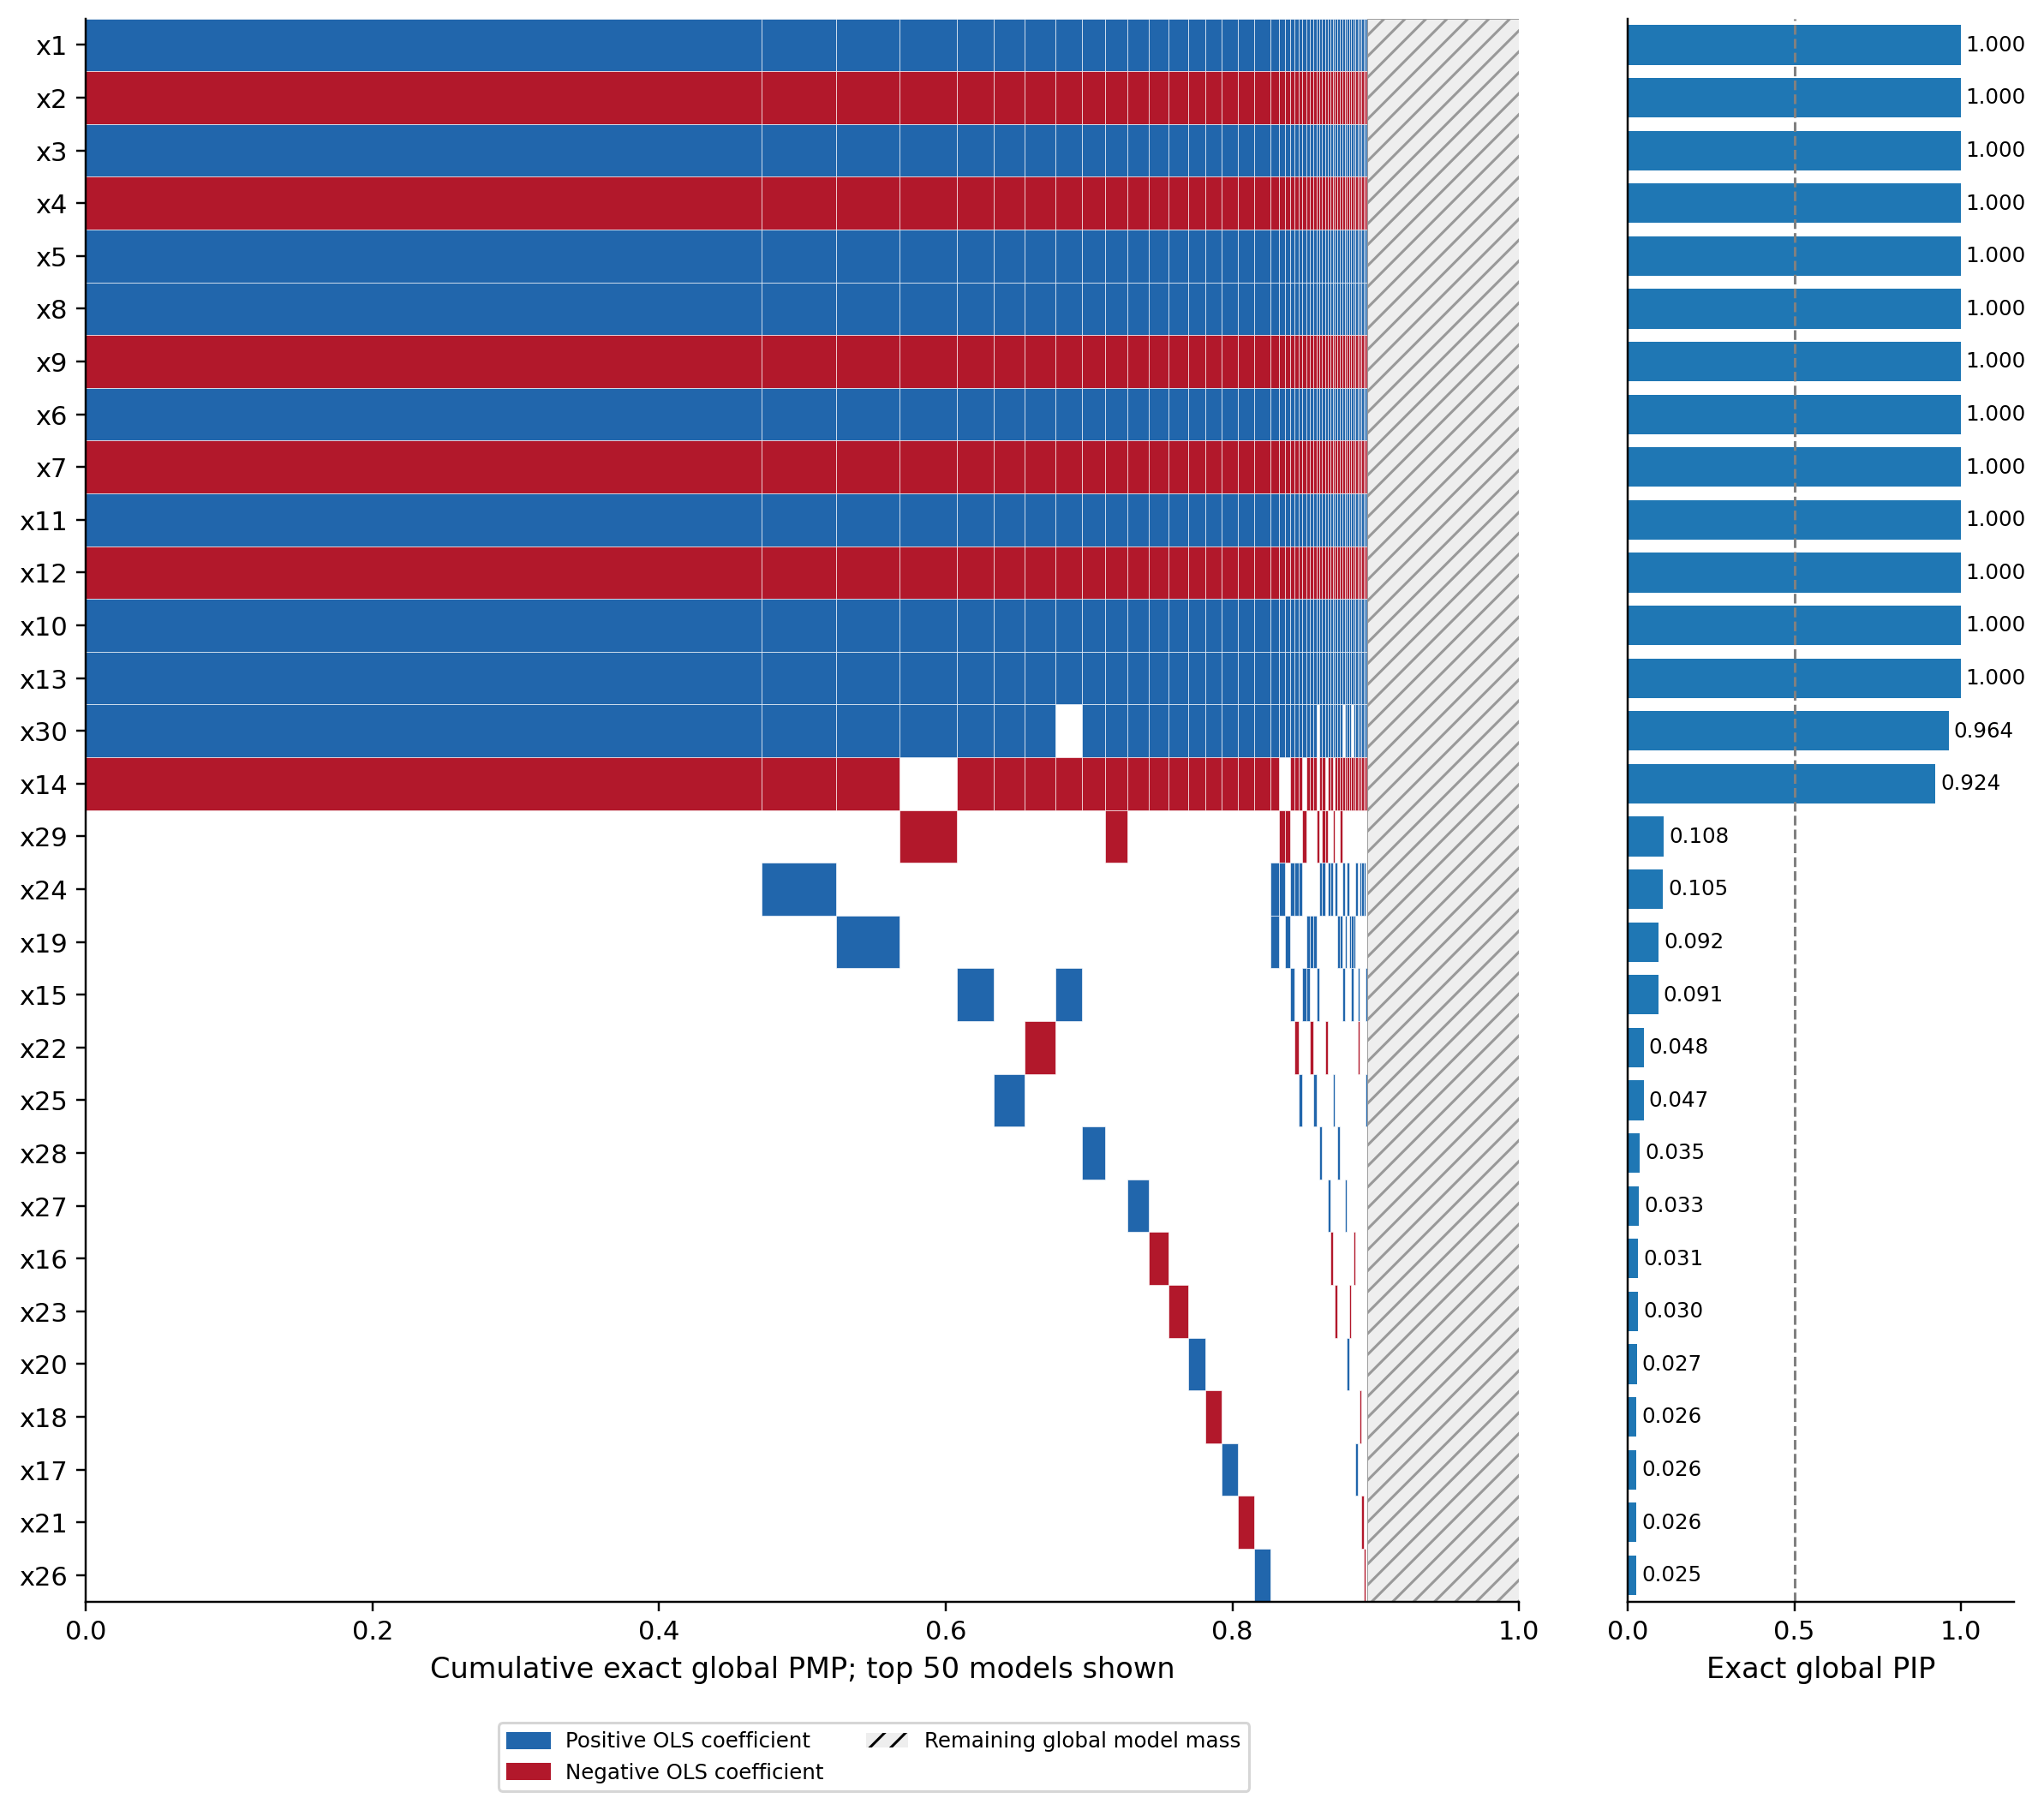

**Notes:** Widths use exact global PMP; inclusion sidebar sums all 2³⁰ models. Cell colors describe model-specific OLS signs. Always-in controls excluded.

In [12]:
display(Markdown('### Exact global variable / model structure'))
display(Image(filename=str(OUTPUT_DIR / '04_exact_global_variable_map.png')))
display(Markdown('**Notes:** Widths use exact global PMP; inclusion sidebar sums all 2³⁰ models. Cell colors describe model-specific OLS signs. Always-in controls excluded.'))

### Exact top models: composition and global model probabilities

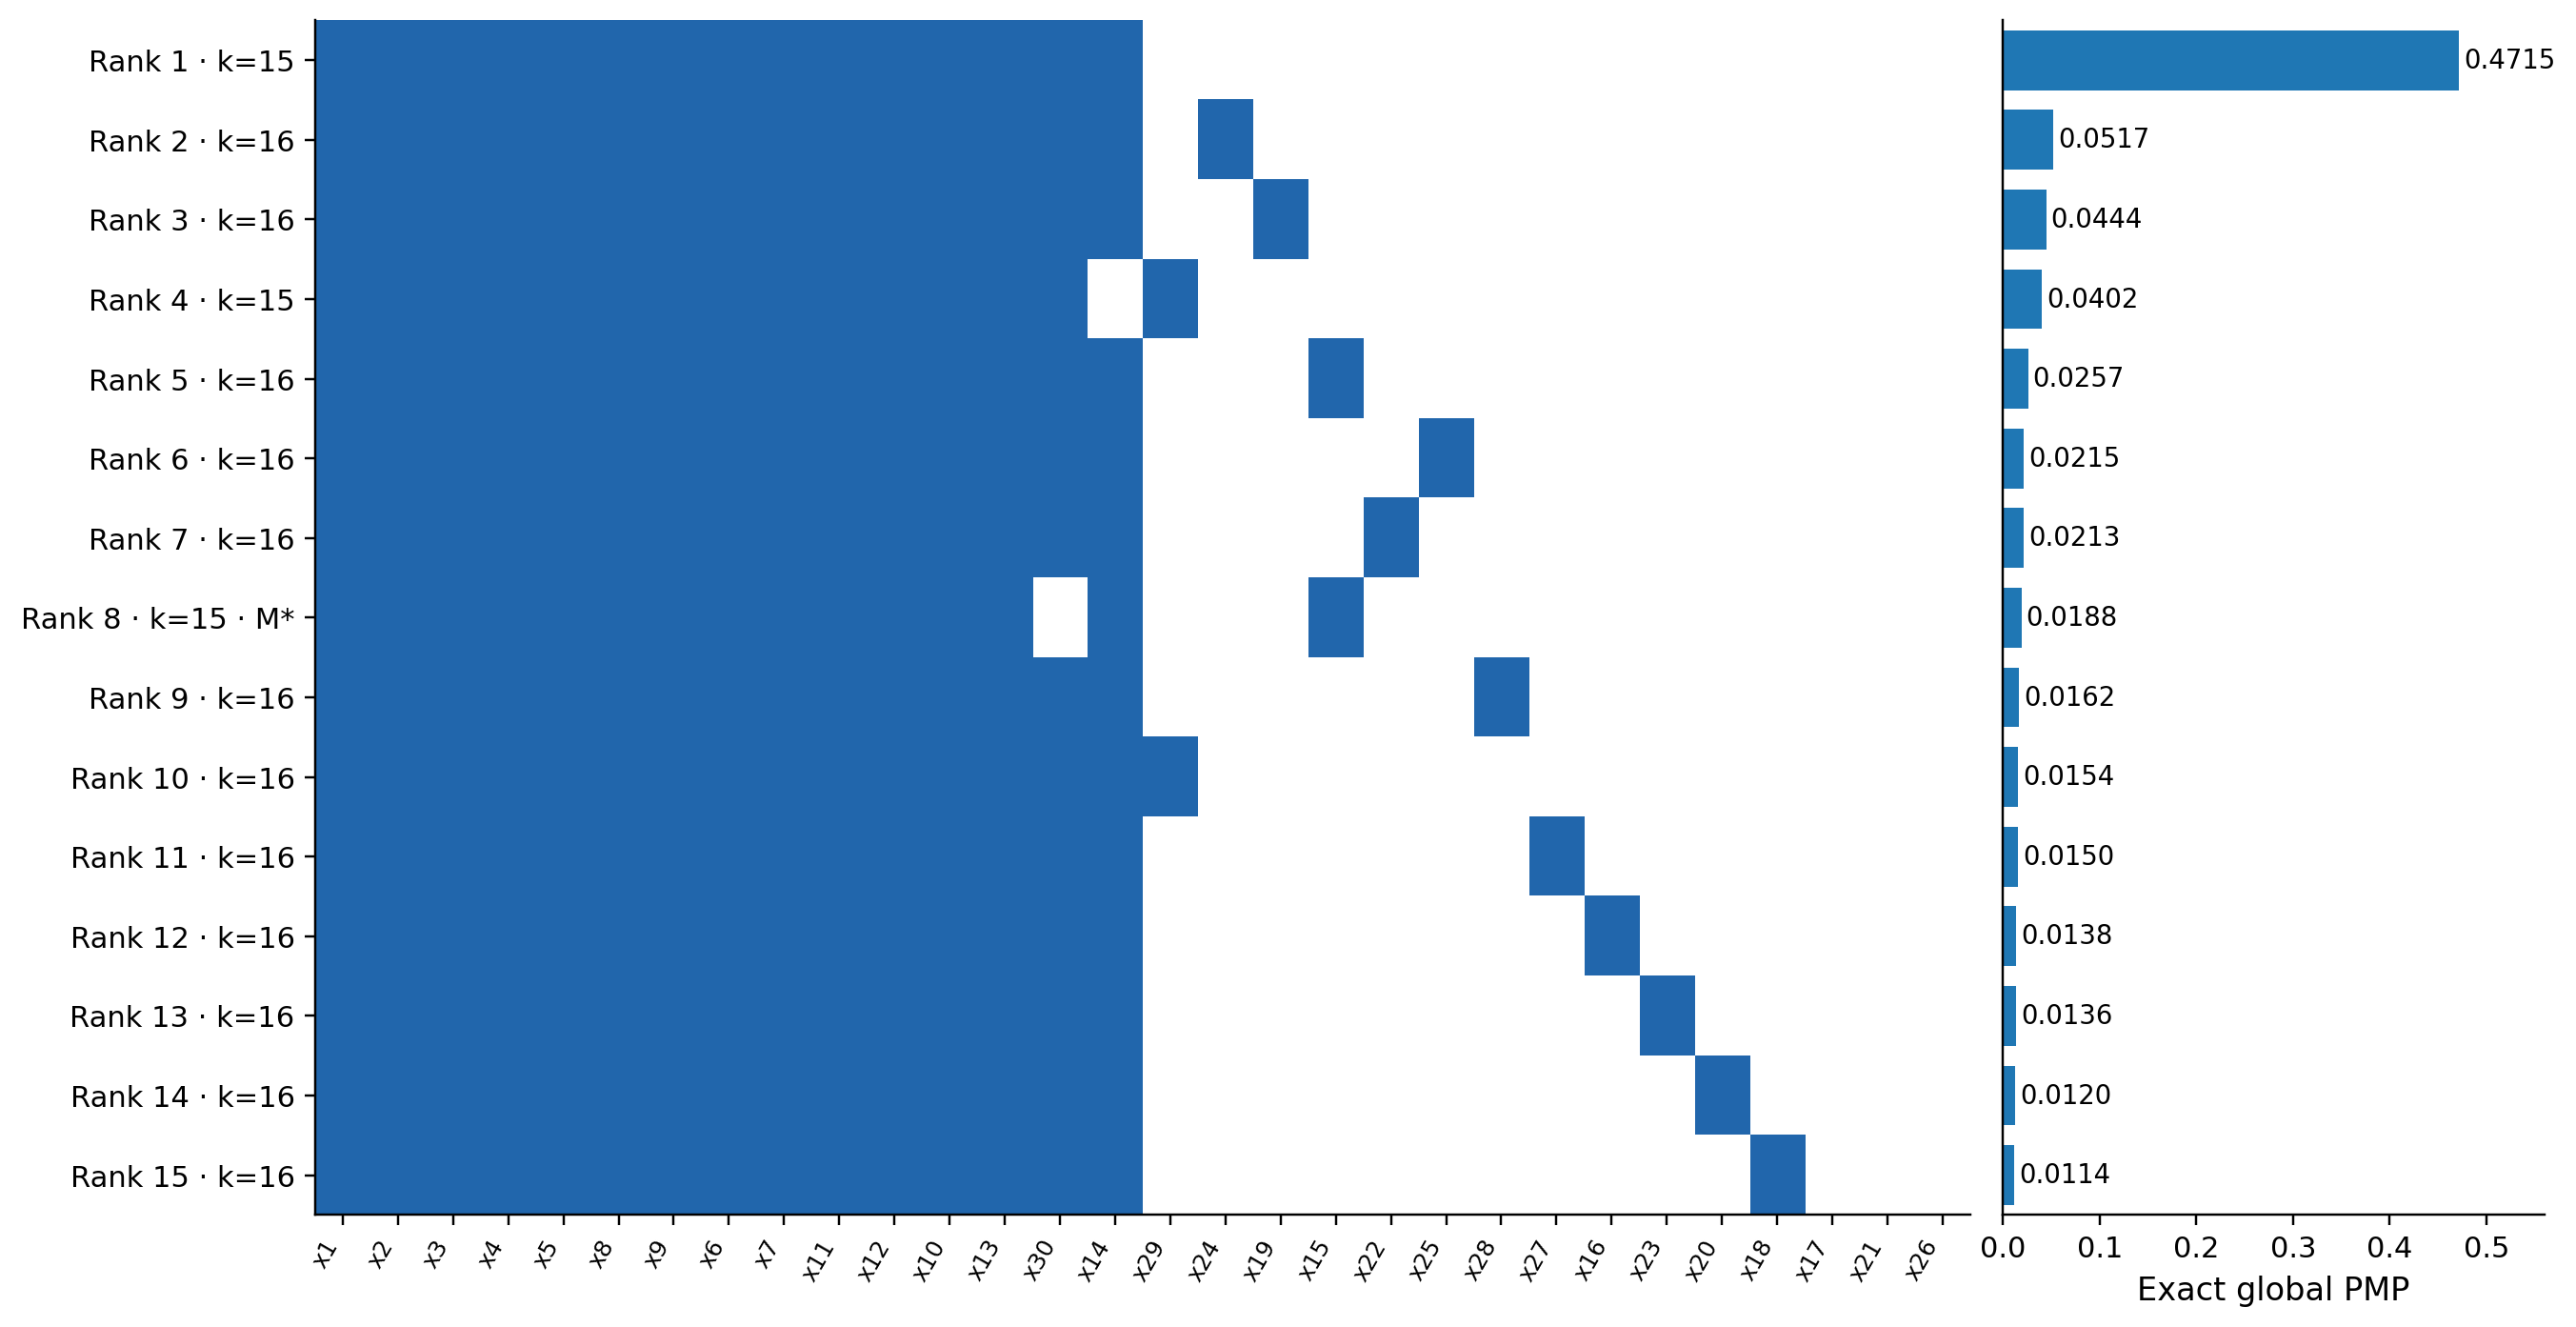

**Notes:** Shared row coordinates preserve rank / composition / weight alignment. Candidates ordered by exact global PIP; w1 and w2 always included.

In [13]:
display(Markdown('### Exact top models: composition and global model probabilities'))
display(Image(filename=str(OUTPUT_DIR / '05_exact_top_models_composition_weights.png')))
display(Markdown('**Notes:** Shared row coordinates preserve rank / composition / weight alignment. Candidates ordered by exact global PIP; w1 and w2 always included.'))

### Exact global posterior model-size distribution

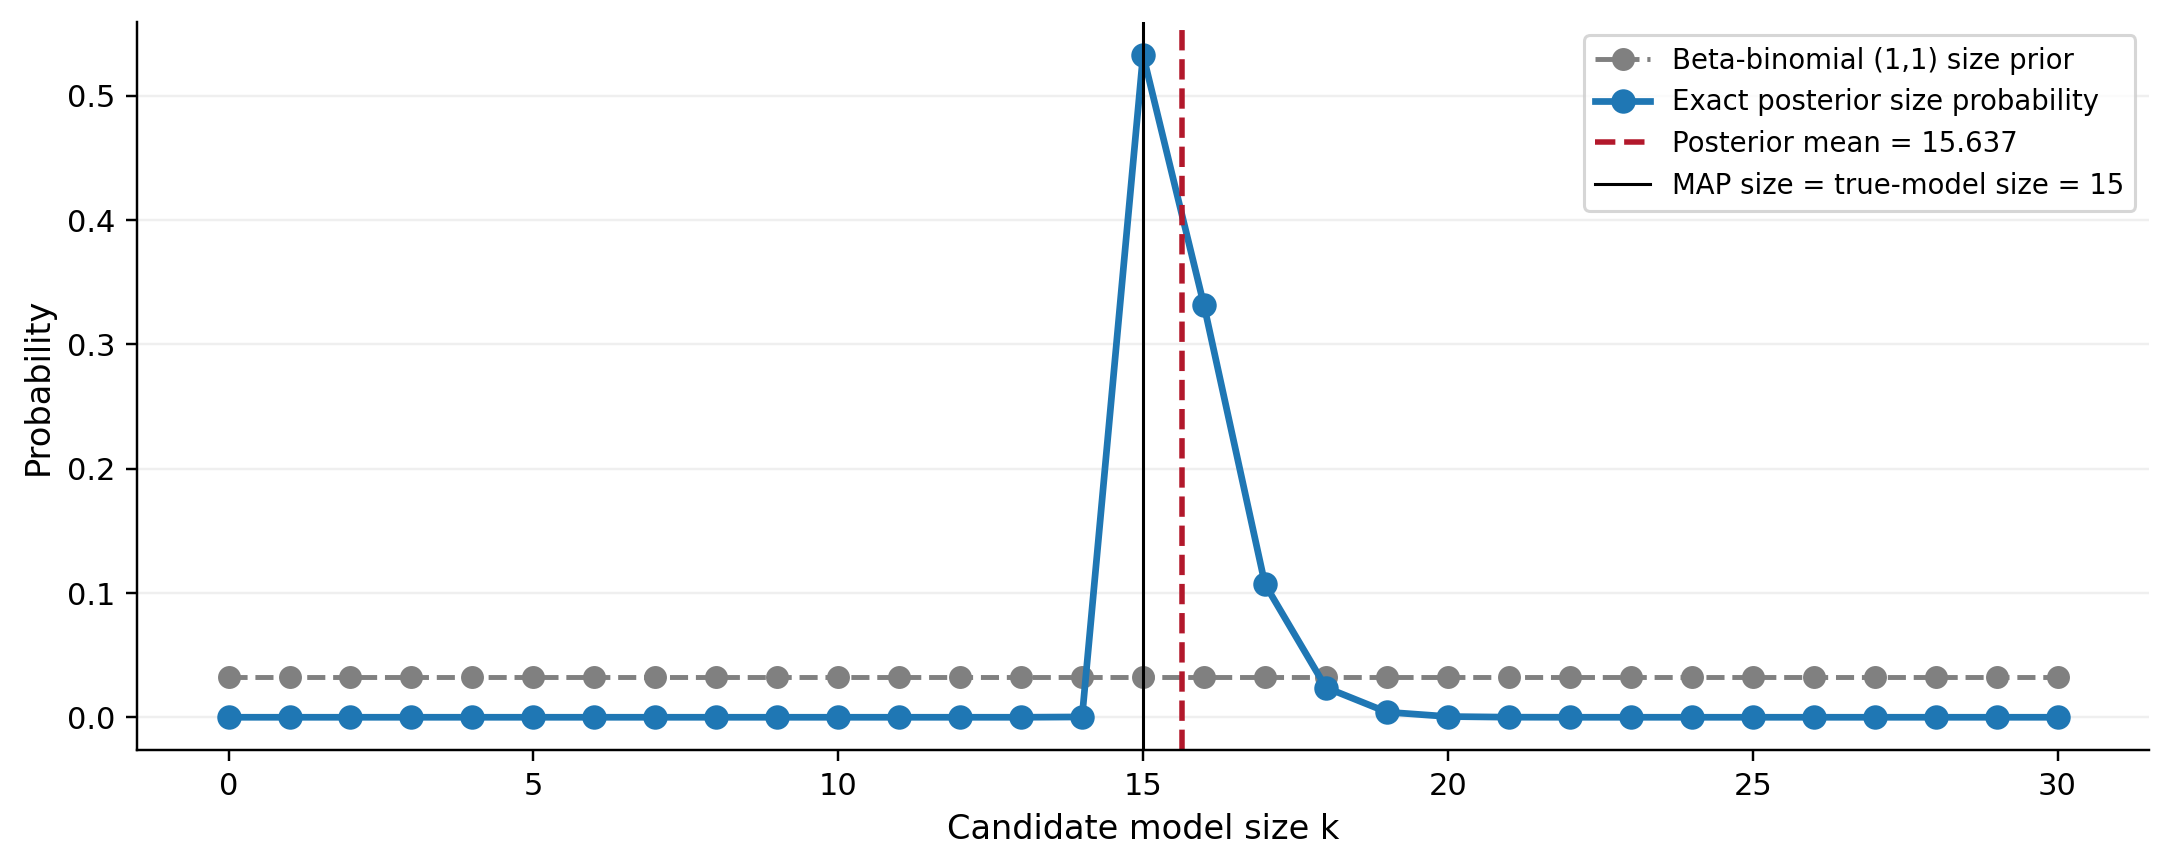

**Notes:** Candidate size excludes the intercept and always-in controls w1, w2. Posterior probabilities aggregate the entire model universe.

In [14]:
display(Markdown('### Exact global posterior model-size distribution'))
display(Image(filename=str(OUTPUT_DIR / '06_exact_global_model_size_distribution.png')))
display(Markdown('**Notes:** Candidate size excludes the intercept and always-in controls w1, w2. Posterior probabilities aggregate the entire model universe.'))

### Exact BMA coefficient structure: archived full-universe mixture

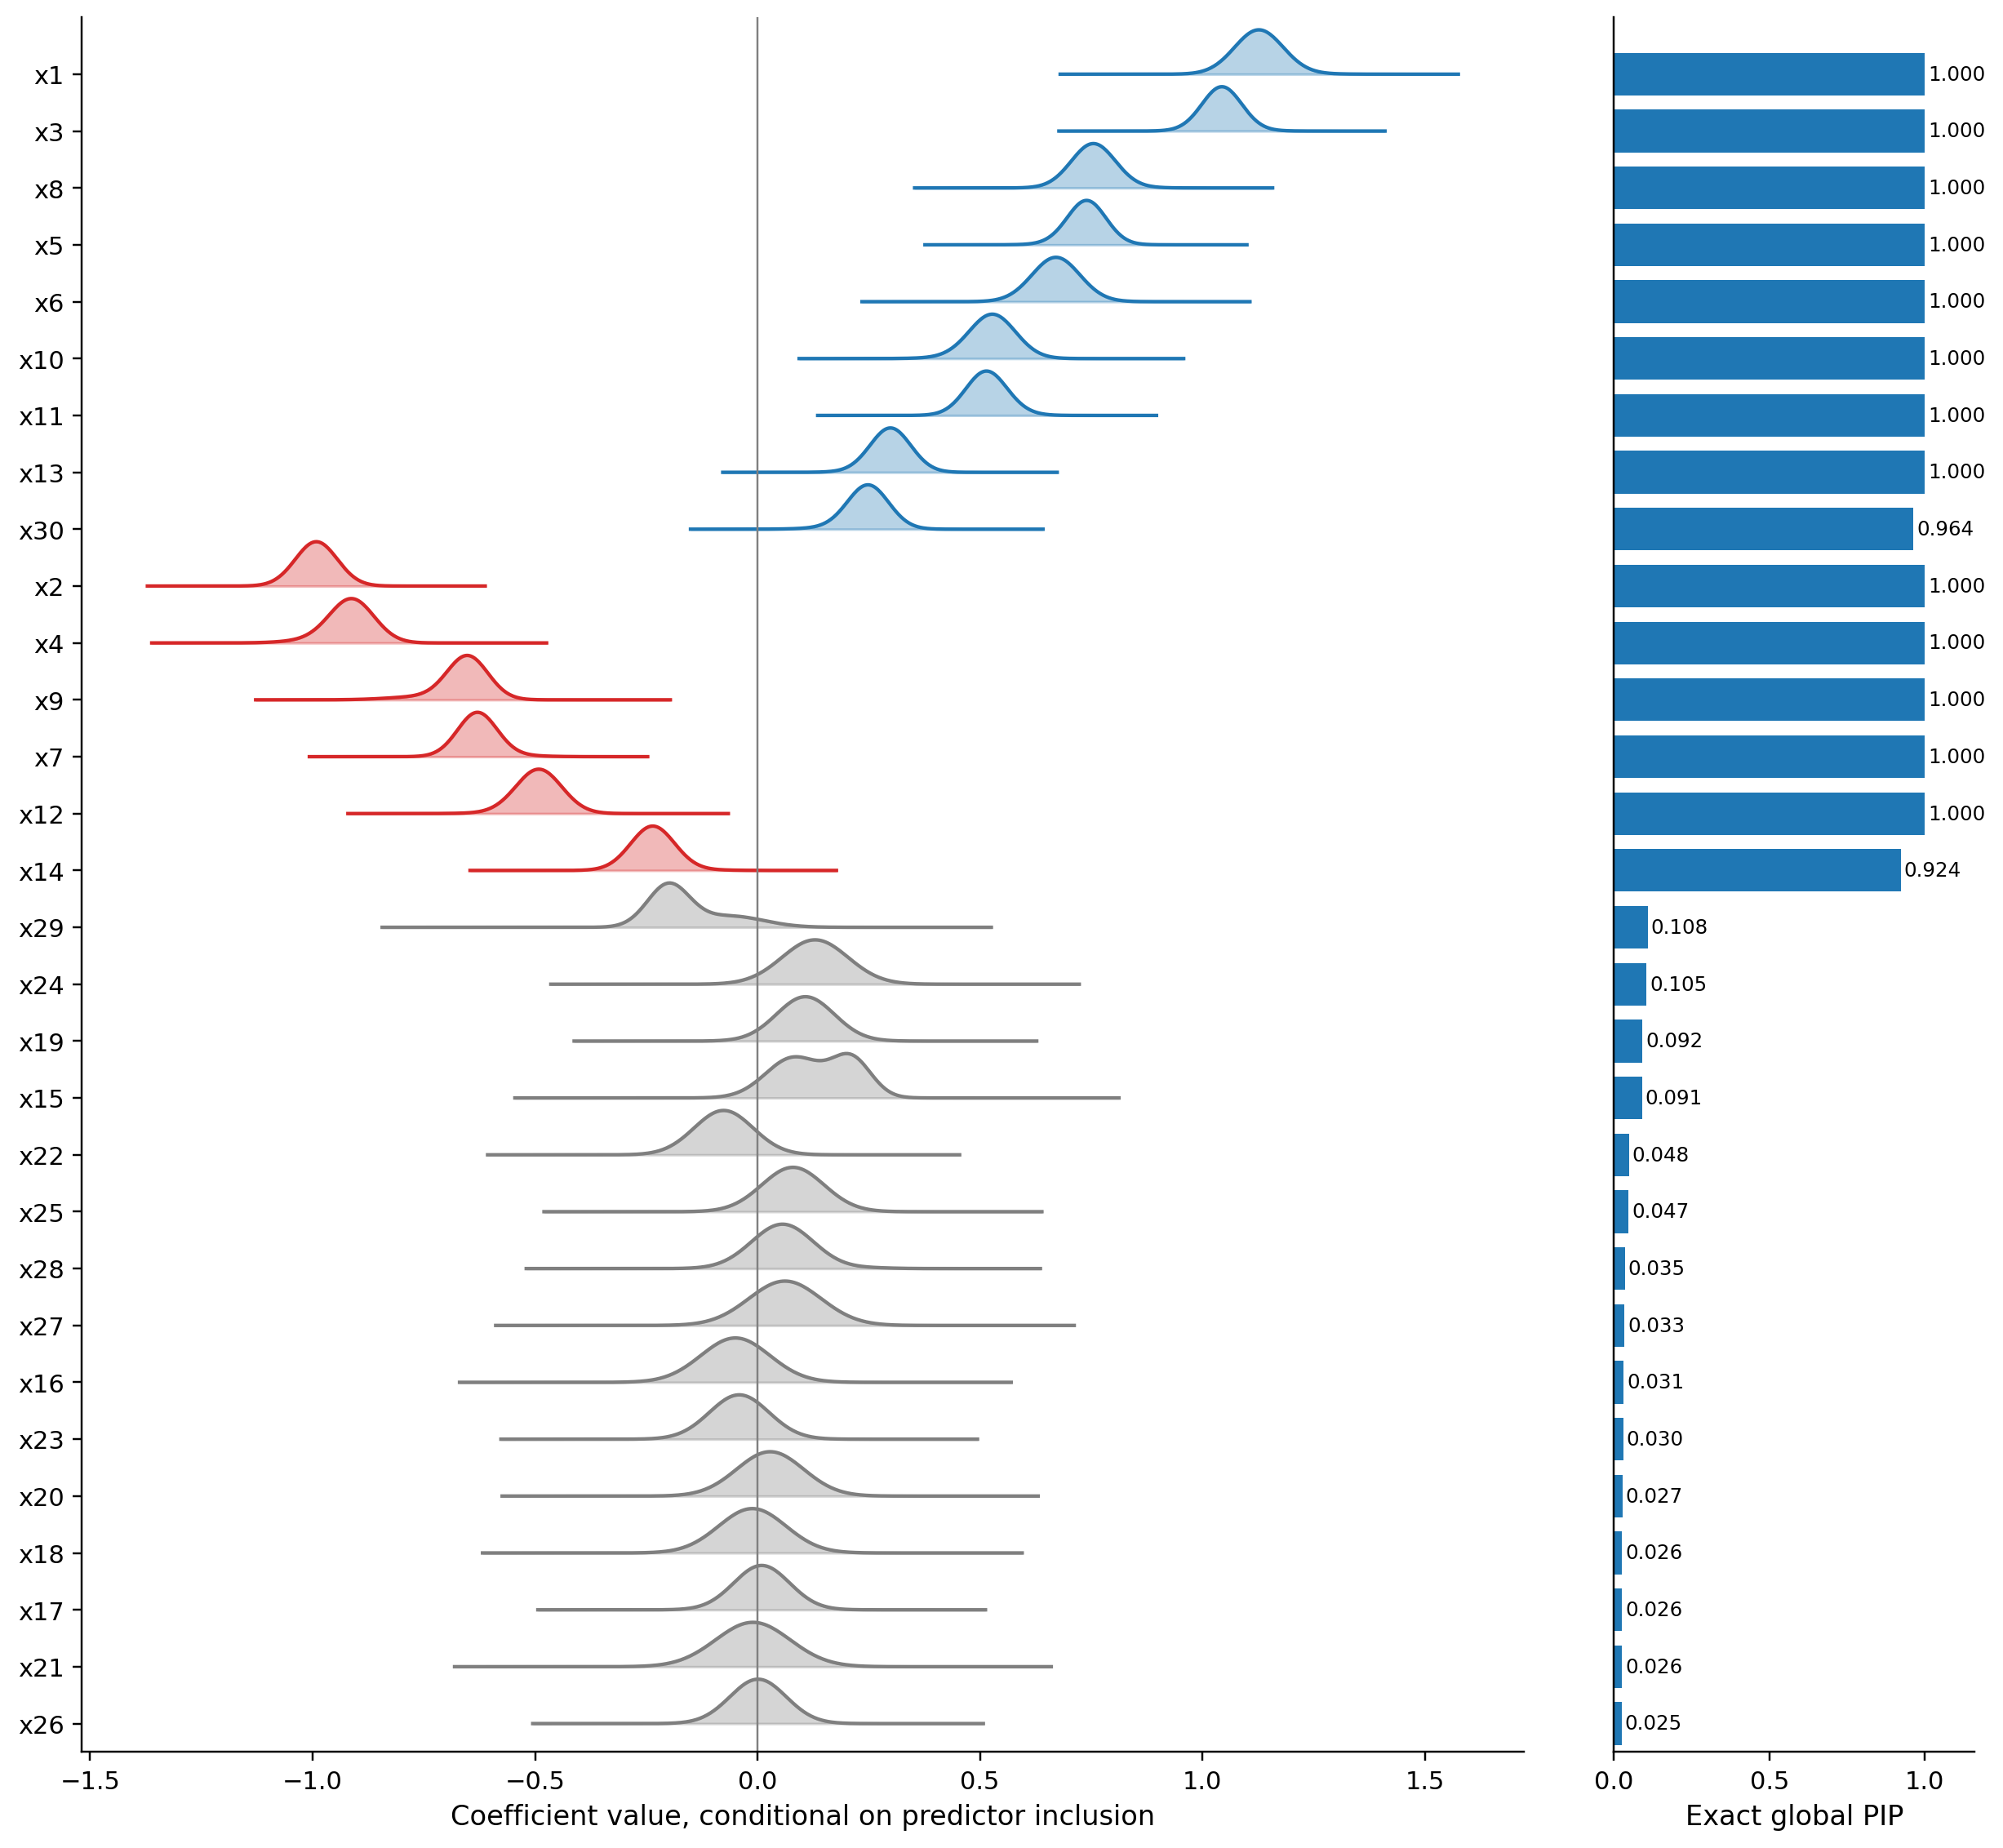

**Notes:** Verified A100 exact-mixture artifact reused on its 257-point grids. Curves condition on inclusion; exclusion atoms at zero omitted. Height is unit-peak. Rows read top to bottom: blue positive effects (largest first), red negative effects (most negative first), then gray predictors (PIP descending). Original colors and inclusion rule are unchanged.

In [15]:
display(Markdown('### Exact BMA coefficient structure: archived full-universe mixture'))
display(Image(filename=str(OUTPUT_DIR / '07_exact_global_coefficient_structure.png')))
display(Markdown('**Notes:** Verified A100 exact-mixture artifact reused on its 257-point grids. Curves condition on inclusion; exclusion atoms at zero omitted. Height is unit-peak. Rows read top to bottom: blue positive effects (largest first), red negative effects (most negative first), then gray predictors (PIP descending). Original colors and inclusion rule are unchanged.'))

### Causal generating model versus exact posterior champion

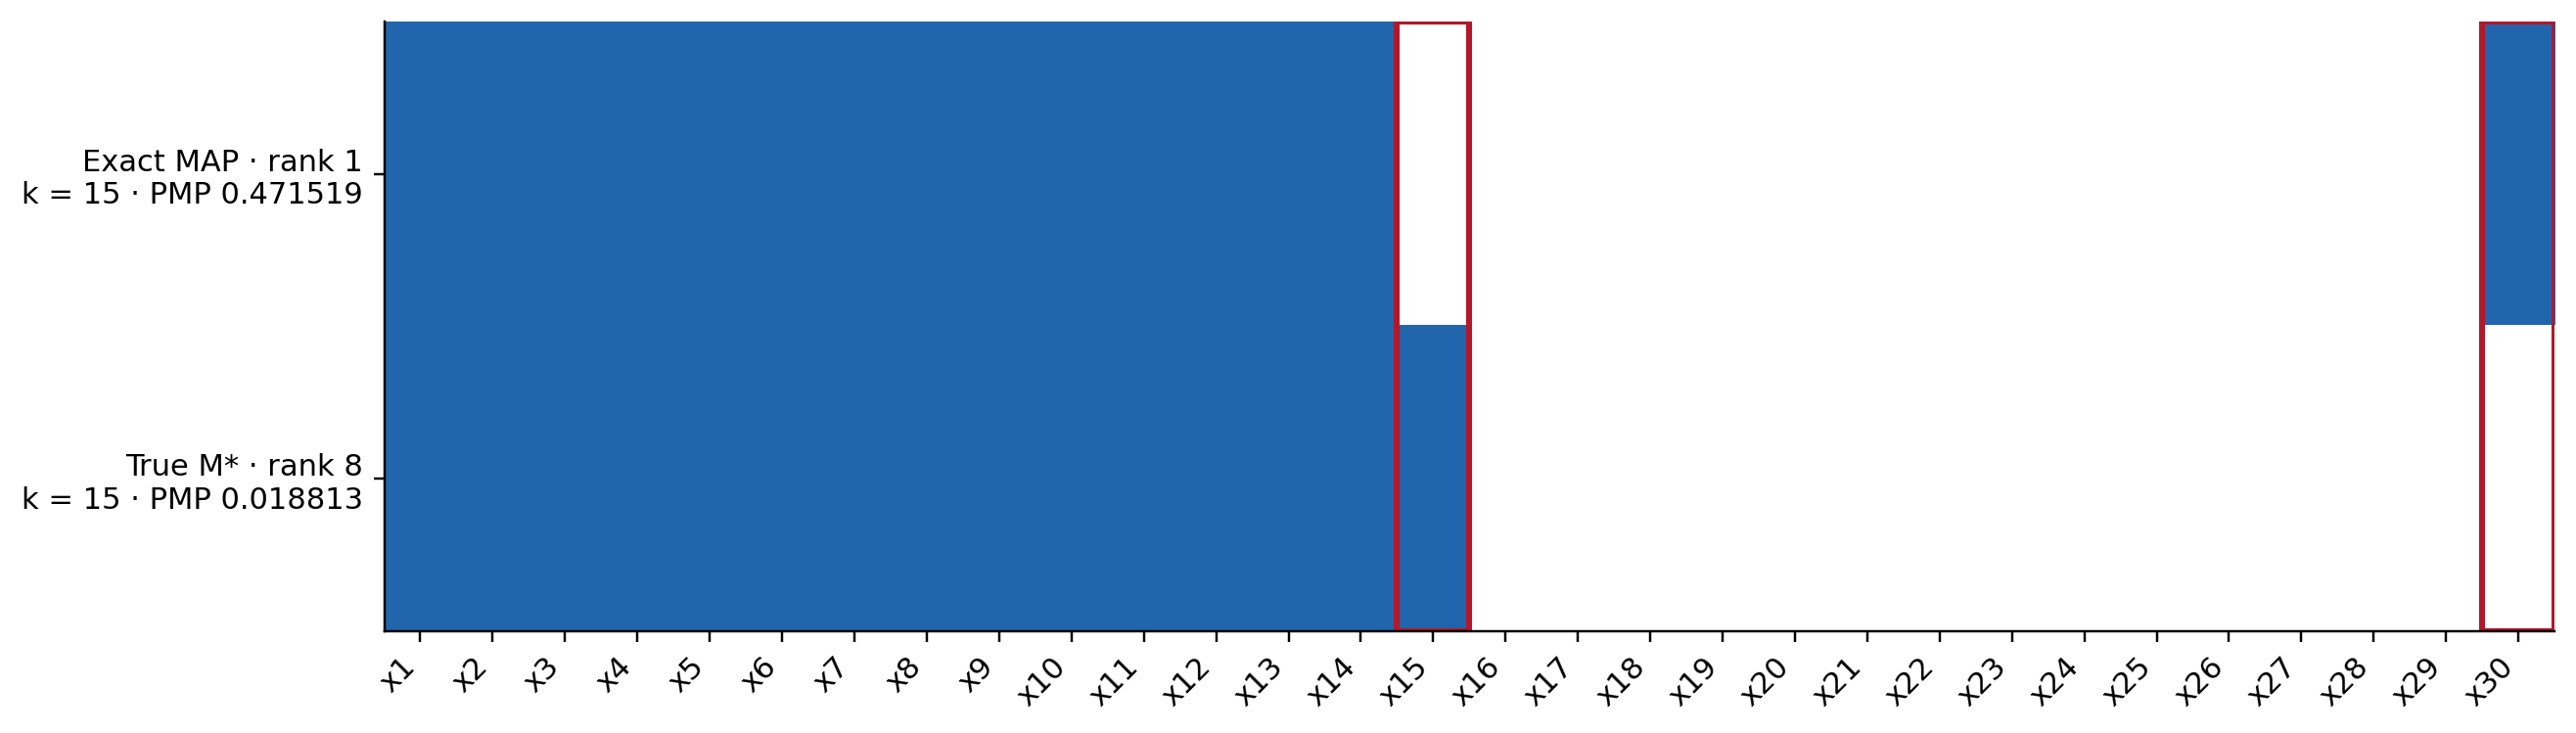

**Notes:** Known synthetic truth is distinct from posterior optimality. Red outlines identify differing predictor indicators; controls w1, w2 are common. Hamming distance = 2; x15 is replaced by proxy x30 in the MAP.

In [16]:
display(Markdown('### Causal generating model versus exact posterior champion'))
display(Image(filename=str(OUTPUT_DIR / '08_exact_true_model_vs_map.png')))
display(Markdown('**Notes:** Known synthetic truth is distinct from posterior optimality. Red outlines identify differing predictor indicators; controls w1, w2 are common. Hamming distance = 2; x15 is replaced by proxy x30 in the MAP.'))

In [17]:
display(Markdown("### Exact top-five regression comparison"))
import pandas as pd
display(pd.read_csv(OUTPUT_DIR / "exact_top5_regression_diagnostics.csv"))
display(Markdown("**Notes:** The exported booktabs table includes a dedicated M* reference panel: x1–x15, size 15, exact rank 8, PMP 0.01881348830750715. MAP is x1–x14+x30, size 15, PMP 0.4715187997893168. The substitution x15 → x30 changes two binary inclusion indicators. Conventional OLS standard errors are not posterior standard deviations."))
print("LaTeX table:", table_path.relative_to(ROOT).as_posix())
print("Exports:", OUTPUT_DIR.relative_to(ROOT).as_posix())
print("\n".join(p.name for p in sorted(OUTPUT_DIR.iterdir()) if p.is_file()))


### Exact top-five regression comparison

,n,k,rank,r2,adjusted_r2,rmse,rse,ll,aic,bic,hqic,exact_global_rank
0,2000,15,18,0.700967,0.698402,1.568256,1.575361,-3737.805062,7513.610124,7620.027270,7552.684269,1
1,2000,16,19,0.701424,0.698711,1.567057,1.574554,-3736.275312,7512.550624,7624.568673,7553.681303,2
2,2000,16,19,0.701378,0.698665,1.567177,1.574675,-3736.428874,7512.857747,7624.875796,7553.988426,3
3,2000,15,18,0.700228,0.697657,1.570191,1.577305,-3740.272226,7518.544453,7624.961599,7557.618598,4
4,2000,16,19,0.701214,0.698499,1.567607,1.575107,-3736.977639,7513.955278,7625.973327,7555.085957,5


**Notes:** The exported booktabs table includes a dedicated M* reference panel: x1–x15, size 15, exact rank 8, PMP 0.01881348830750715. MAP is x1–x14+x30, size 15, PMP 0.4715187997893168. The substitution x15 → x30 changes two binary inclusion indicators. Conventional OLS standard errors are not posterior standard deviations.

LaTeX table: outputs/exact_p30/exact_top5_regression_comparison.tex
Exports: outputs/exact_p30
00_predictor_correlogram.png
01_exhaustive_model_space_cloud.png
02_exhaustive_reticular_ridgeline.png
03_exhaustive_reticular_frontiers.png
04_exact_global_variable_map.png
05_exact_top_models_composition_weights.png
06_exact_global_model_size_distribution.png
07_exact_global_coefficient_structure.png
08_exact_true_model_vs_map.png
exact_benchmark_metadata.json
exact_frontiers.csv
exact_global_pips.csv
exact_map.json
exact_model_size_distribution.csv
exact_top10000_models.csv
exact_top100_models.csv
exact_top10_models.csv
exact_top5_ols_coefficients.csv
exact_top5_regression_comparison.tex
exact_top5_regression_diagnostics.csv
exact_true_model.json
exhaustive_reticular_summary.csv
figure_presentation.json
predictor_correlations.csv
